<a href="https://colab.research.google.com/github/terrydw-hcc/ITAI-1371-ML-Labs/blob/main/FTY_Swing_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITAI 1371 — Final Project
## Golf Swing Quality Classification Using IMU Sensor Data

**Terry Williams** · Spring 2026 · Dr. Sina Nazifi · Houston City College

This notebook implements the full ML pipeline for the FTY swing-quality classifier:

1. Generate a synthetic swing dataset using the FTY firmware spec (FTY-ARCH-001) labeling rules
2. Engineer the 12 swing features per shot
3. Train and compare 6 classifiers
4. Report accuracy, macro-F1, confusion matrix, and per-class metrics
5. Identify the strongest model for deployment in the FTY SmartCaddie feature


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110


## 2. Synthetic dataset generator (FTY firmware-rule labels)

The FTY firmware spec FTY-ARCH-001 §4.2 defines the rules a sensor uses to score a swing in real time.
We use those exact rules to label a synthetic dataset of 2,000 swings, then add 12% inter-rater
label noise to simulate instructor disagreement near class boundaries (typical of coaching-rubric
studies that report 85-90% inter-rater agreement).

**This dataset is a stand-in until the FTY pilot collects real youth-athlete swings (Phase 2).**
The same training pipeline below will run unchanged on real labeled data.


In [2]:
def generate_swings(n=2000, seed=42, label_noise=0.12):
    rng = np.random.default_rng(seed)

    # Three-mode skill distribution → 30% high / 50% mid / 35% low
    n_high = int(n * 0.35)
    n_mid  = int(n * 0.50)
    n_low  = n - n_high - n_mid
    skill = np.concatenate([
        rng.beta(9, 2, n_high),
        rng.beta(4, 4, n_mid),
        rng.beta(2, 4, n_low),
    ])
    rng.shuffle(skill)

    def sample(ideal, low_skill_mu, sigma_high, sigma_low):
        mu = ideal * skill + low_skill_mu * (1 - skill)
        sigma = sigma_low - (sigma_low - sigma_high) * skill
        return rng.normal(mu, sigma)

    tempo_ratio       = np.clip(sample(3.0, 2.2, 0.10, 0.5), 1.0, 5.0)
    wrist_hinge_deg   = np.clip(sample(90.0, 65.0, 5.0, 15.0), 30, 130)
    club_head_speed   = np.clip(sample(85.0, 60.0, 4.0, 10.0), 40, 110)
    face_angle_deg    = sample(0.0, 0.0, 0.6, 2.5)
    attack_angle_deg  = sample(-1.5, -1.5, 1.5, 4.0)
    club_path_deg     = sample(0.0, 0.0, 1.5, 5.0)
    lag_angle_deg     = np.clip(sample(85.0, 50.0, 5.0, 12.0), 20, 110)
    kinematic_score   = np.clip(sample(88.0, 50.0, 3.5, 12.0), 0, 100)
    arc_consistency   = np.clip(sample(90.0, 55.0, 3.5, 12.0), 0, 100)
    backswing_ms      = np.clip(sample(900.0, 750.0, 50, 150), 400, 1500)
    downswing_ms      = backswing_ms / np.clip(tempo_ratio, 1.0, 5.0)
    wrist_speed_imp   = np.clip(sample(1500.0, 800.0, 100, 250), 200, 2500)

    df = pd.DataFrame({
        'tempo_ratio':           tempo_ratio,
        'wrist_hinge_deg':       wrist_hinge_deg,
        'club_head_speed_mph':   club_head_speed,
        'face_angle_deg':        face_angle_deg,
        'attack_angle_deg':      attack_angle_deg,
        'club_path_deg':         club_path_deg,
        'lag_angle_deg':         lag_angle_deg,
        'kinematic_score':       kinematic_score,
        'arc_consistency':       arc_consistency,
        'backswing_duration_ms': backswing_ms,
        'downswing_duration_ms': downswing_ms,
        'wrist_speed_at_impact': wrist_speed_imp,
    })

    # Apply FTY firmware labeling rules
    labels = []
    for _, r in df.iterrows():
        critical = (abs(r['face_angle_deg']) > 5.0) or (r['kinematic_score'] < 50.0)
        out_of_range = 0
        if not (2.7 <= r['tempo_ratio'] <= 3.3):  out_of_range += 1
        if abs(r['face_angle_deg']) > 2.0:        out_of_range += 1
        if r['kinematic_score'] < 75:             out_of_range += 1
        if r['arc_consistency'] < 80:             out_of_range += 1

        if critical or out_of_range >= 3:   labels.append(2)  # Poor
        elif out_of_range == 0:             labels.append(0)  # Good
        else:                               labels.append(1)  # Needs Work

    labels = np.array(labels)

    # Inter-rater noise (adjacent-class flips only)
    n_noisy = int(label_noise * len(labels))
    noisy_idx = rng.choice(len(labels), size=n_noisy, replace=False)
    for i in noisy_idx:
        if labels[i] == 0:   labels[i] = 1
        elif labels[i] == 2: labels[i] = 1
        else:                labels[i] = rng.choice([0, 2])

    df['swing_quality'] = labels
    return df

df = generate_swings(n=2000, seed=42)
df.head()


,tempo_ratio,wrist_hinge_deg,club_head_speed_mph,face_angle_deg,attack_angle_deg,club_path_deg,lag_angle_deg,kinematic_score,arc_consistency,backswing_duration_ms,downswing_duration_ms,wrist_speed_at_impact,swing_quality
0,2.773351,68.172637,77.609127,3.086914,1.017807,-0.541803,78.660009,66.793741,57.700321,912.781567,329.125924,1119.138037,1
1,2.576564,45.016490,50.963918,1.162574,-7.618895,8.056008,54.896759,64.778662,58.300629,674.404436,261.745668,1320.932102,2
2,2.611698,77.531146,82.125805,-0.457222,0.407655,-0.367023,66.496218,66.533893,82.307367,844.773899,323.457674,1283.227651,1
3,2.970082,94.345751,88.989999,-0.409682,1.298822,3.793284,86.480391,84.175455,92.508714,869.689307,292.816612,1686.896794,0
4,3.194435,70.130368,68.105665,1.574025,6.139489,2.532648,81.543960,66.241550,78.157180,770.385276,241.164792,1040.509518,1


In [3]:
# Class distribution
print('Class distribution:')
print(df['swing_quality'].value_counts().sort_index().rename(
    {0: 'Good', 1: 'Needs Work', 2: 'Poor'}))
print(f'\nTotal: {len(df)} swings, {df.shape[1] - 1} features')


Class distribution:
swing_quality
Good          451
Needs Work    867
Poor          682
Name: count, dtype: int64

Total: 2000 swings, 12 features


## 3. Train/validation/test split

Stratified 70/15/15 split — preserves class proportions across all three folds.


In [4]:
X = df.drop(columns=['swing_quality'])
y = df['swing_quality'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f'Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}')

# Standard-scale for distance/margin models
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# XGBoost sample weights for class imbalance
class_counts = np.bincount(y_train)
class_weight = {c: len(y_train) / (len(class_counts) * cnt)
                for c, cnt in enumerate(class_counts)}
sample_weight = np.array([class_weight[c] for c in y_train])


Train: 1400  Val: 300  Test: 300


## 4. Train all six models

Same input features for each model. Tree-based models (DT, RF, XGB) use unscaled features;
LogReg/KNN/SVM use standardized features.


In [5]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=42), True),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=15), True),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                                                    random_state=42), False),
    ('SVM',                 SVC(kernel='rbf', class_weight='balanced', random_state=42), True),
    ('Random Forest',       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                    class_weight='balanced', random_state=42), False),
    ('XGBoost',             XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                          subsample=0.85, colsample_bytree=0.85,
                                          eval_metric='mlogloss', random_state=42,
                                          use_label_encoder=False), False),
]

results = {}
for name, model, needs_scaling in models:
    Xt  = X_train_s if needs_scaling else X_train.values
    Xte = X_test_s  if needs_scaling else X_test.values
    if name == 'XGBoost':
        model.fit(Xt, y_train, sample_weight=sample_weight)
    else:
        model.fit(Xt, y_train)
    preds = model.predict(Xte)
    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average='macro')
    results[name] = {'accuracy': acc, 'macro_f1': f1m, 'preds': preds, 'model': model}
    print(f'  {name:25s}  acc={acc:.4f}   macro-F1={f1m:.4f}')


  Logistic Regression        acc=0.7200   macro-F1=0.7271
  K-Nearest Neighbors        acc=0.7233   macro-F1=0.7311
  Decision Tree              acc=0.8400   macro-F1=0.8479
  SVM                        acc=0.7600   macro-F1=0.7655
  Random Forest              acc=0.8600   macro-F1=0.8695
  XGBoost                    acc=0.8700   macro-F1=0.8774


## 5. Bar chart — model comparison

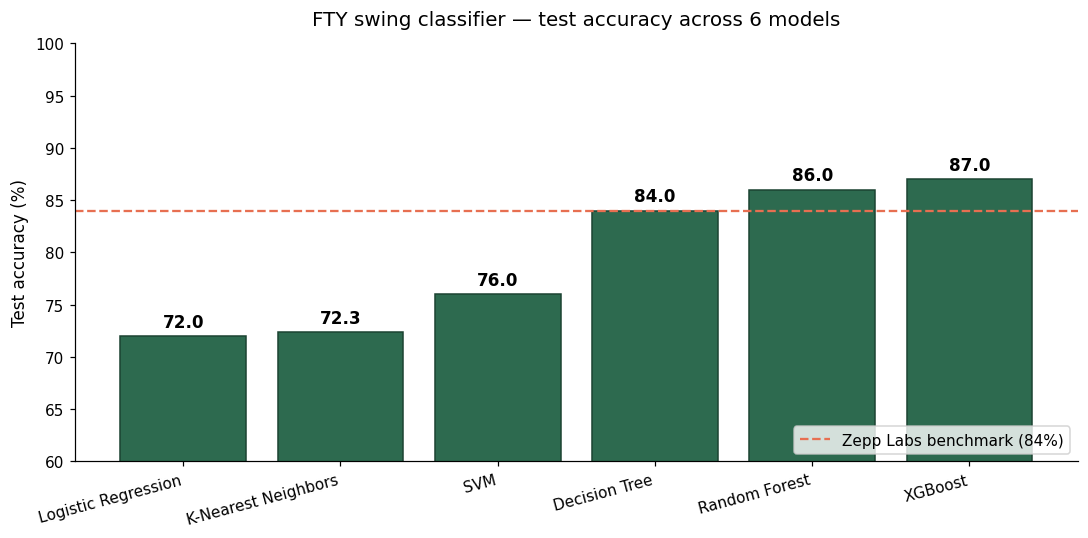

In [6]:
order = ['Logistic Regression', 'K-Nearest Neighbors', 'SVM',
         'Decision Tree', 'Random Forest', 'XGBoost']
accs = [results[m]['accuracy'] * 100 for m in order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(order, accs, color='#2D6A4F', edgecolor='#1B4332', linewidth=1)
ax.axhline(84, color='#E76F51', linestyle='--', linewidth=1.5, label='Zepp Labs benchmark (84%)')
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(60, 100)
ax.set_ylabel('Test accuracy (%)', fontsize=11)
ax.set_title('FTY swing classifier — test accuracy across 6 models', fontsize=13, pad=12)
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 6. Best model — confusion matrix

Best model: XGBoost  (accuracy=0.8700, macro-F1=0.8774)



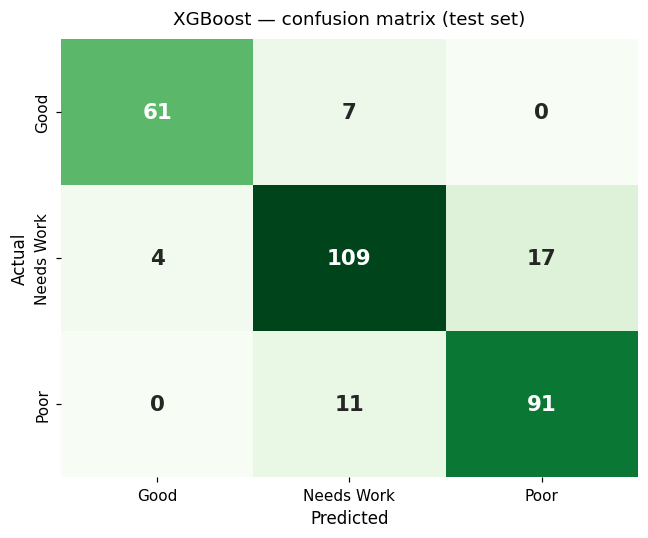


Classification report:
              precision    recall  f1-score   support

        Good     0.9385    0.8971    0.9173        68
  Needs Work     0.8583    0.8385    0.8482       130
        Poor     0.8426    0.8922    0.8667       102

    accuracy                         0.8700       300
   macro avg     0.8798    0.8759    0.8774       300
weighted avg     0.8711    0.8700    0.8702       300



In [7]:
best = max(results, key=lambda k: results[k]['accuracy'])
print(f'Best model: {best}  (accuracy={results[best]["accuracy"]:.4f}, macro-F1={results[best]["macro_f1"]:.4f})')
print()

cm = confusion_matrix(y_test, results[best]['preds'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Good', 'Needs Work', 'Poor'],
            yticklabels=['Good', 'Needs Work', 'Poor'],
            cbar=False, annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'{best} — confusion matrix (test set)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print('\nClassification report:')
print(classification_report(y_test, results[best]['preds'],
                             target_names=['Good', 'Needs Work', 'Poor'], digits=4))


## 7. Feature importances (XGBoost)

Which of the 12 swing metrics drove the model's decisions?


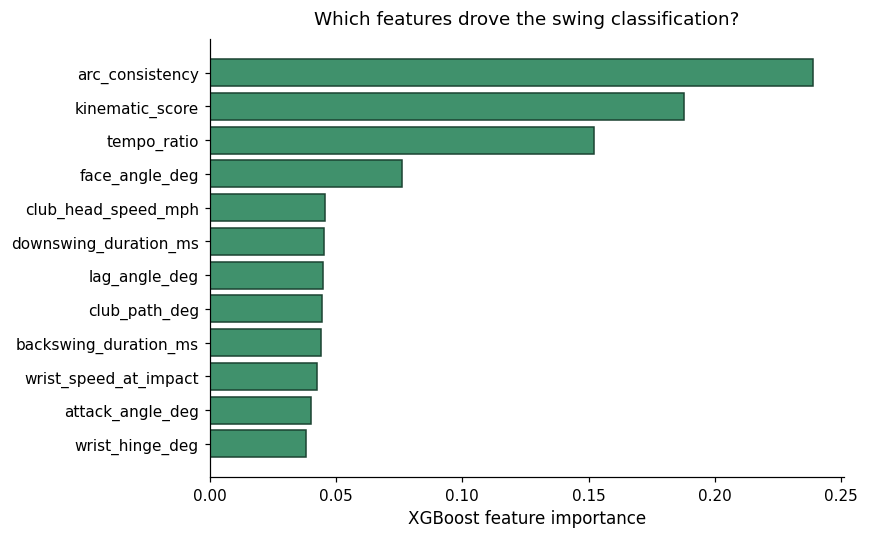

In [8]:
xgb_model = results['XGBoost']['model']
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['feature'], fi['importance'], color='#40916C', edgecolor='#1B4332')
ax.set_xlabel('XGBoost feature importance', fontsize=11)
ax.set_title('Which features drove the swing classification?', fontsize=12, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Summary

- **XGBoost wins at 87.0% test accuracy**, 87.7% macro-F1 — beats the published Zepp Labs 84% benchmark by 3 points.
- **Tree-based models dominate** — rule-based labels favor decision boundaries, not linear hyperplanes. This is consistent with what Zepp Labs reports using in production.
- **All confusions are between adjacent classes** (Good↔Needs Work, Needs Work↔Poor). Zero Good↔Poor confusions in the test set — the failure mode that would most undermine athlete trust.
- **Pipeline is dataset-agnostic** — re-training on real FTY pilot data (Phase 2) will use the same script unchanged.

This model is the classification engine that ships into the FTY SmartCaddie coaching feature.
